# Hotel Reservations Prediction

This Project aims to create a entire Machine Learning project to predict if the customer is going to honor the reservation or cancel it.

## Use case - Why do we need this model?

In this section we will talk about why we are making this project and for whom we are making this project and for this I also separated in three main target that we will approach.

1. **Revenue Management** -  Don't suffer any loos cause by overbooking
2. **Target Marketing** - Identify which is the costumer characteristics to fit the costumer expectations and may also personalize offers.
3. **Fraud Detection** - Identify the costumer characteristic thar often scams and try to avoid future costumers that might scam.

Is important to noticed that in this particular case our audience is Hotel or anyone who wants to work with hostelry such as `AirBnB`

# Setup

In [90]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

import joblib

from config.paths_config import *  

# Read the data

## [Dataset](https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset)

The online hotel reservation channels have dramatically changed booking possibilities and customers’ behavior. A significant number of hotel reservations are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with.

In [2]:
# Jupyter starts in 'notebooks/' path; whereas 'paths_config' uses relative paths
PROJECT_ROOT = os.path.dirname(os.getcwd())
PROJECT_TRAIN_FILE_PATH = os.path.join(PROJECT_ROOT, TRAIN_FILE_PATH)
df = pd.read_csv(PROJECT_TRAIN_FILE_PATH)
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN25630,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,INN14474,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,INN23721,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,INN05844,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,INN18710,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


**Data Dictionary**

- **Booking_ID**: unique identifier of each booking
- **no_of_adults**: Number of adults
- **no_of_children**: Number of Children
- **no_of_weekend_nights**: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- **no_of_week_nights**: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- **type_of_meal_plan**: Type of meal plan booked by the customer:
- **required_car_parking_space**: Does the customer require a car parking space? (0 - No, 1- Yes)
- **room_type_reserved**: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
- **lead_time**: Number of days between the date of booking and the arrival date
- **arrival_year**: Year of arrival date
- **arrival_month**: Month of arrival date
- **arrival_date**: Date of the month
- **market_segment_type**: Market segment designation.
- **repeated_guest**: Is the customer a repeated guest? (0 - No, 1- Yes)
- **no_of_previous_cancellations**: Number of previous bookings that were canceled by the customer prior to the current booking
- **no_of_previous_bookings_not_canceled**: Number of previous bookings not canceled by the customer prior to the current booking
- **avg_price_per_room**: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- **no_of_special_requests**: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- **booking_status**: Flag indicating if the booking was canceled or not.

In [3]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29020 entries, 0 to 29019
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29020 non-null  str    
 1   no_of_adults                          29020 non-null  int64  
 2   no_of_children                        29020 non-null  int64  
 3   no_of_weekend_nights                  29020 non-null  int64  
 4   no_of_week_nights                     29020 non-null  int64  
 5   type_of_meal_plan                     29020 non-null  str    
 6   required_car_parking_space            29020 non-null  int64  
 7   room_type_reserved                    29020 non-null  str    
 8   lead_time                             29020 non-null  int64  
 9   arrival_year                          29020 non-null  int64  
 10  arrival_month                         29020 non-null  int64  
 11  arrival_date              

In [5]:
df.drop(columns=["Booking_ID"], inplace=True)

In [6]:
df.shape

(29020, 18)

In [7]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [8]:
df.isna().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(7661)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(21359, 18)

In [12]:
df["no_of_adults"].value_counts()

no_of_adults
2    15489
1     3996
3     1748
0      113
4       13
Name: count, dtype: int64

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,21359.0,1.885388,0.528583,0.0,2.00,2.0,2.0,4.0
no_of_children,21359.0,0.140081,0.461399,0.0,0.00,0.0,0.0,10.0
no_of_weekend_nights,21359.0,0.875977,0.883633,0.0,0.00,1.0,2.0,6.0
no_of_week_nights,21359.0,2.252914,1.496848,0.0,1.00,2.0,3.0,17.0
required_car_parking_space,21359.0,0.042465,0.201651,0.0,0.00,0.0,0.0,1.0
lead_time,21359.0,67.388501,69.289723,0.0,12.00,45.0,101.0,443.0
arrival_year,21359.0,2017.849338,0.357728,2017.0,2018.00,2018.0,2018.0,2018.0
arrival_month,21359.0,7.340138,3.127663,1.0,5.00,8.0,10.0,12.0
arrival_date,21359.0,15.754951,8.857233,1.0,8.00,16.0,23.0,31.0
repeated_guest,21359.0,0.032399,0.177060,0.0,0.00,0.0,0.0,1.0


### Distribution Analysis of Numerical Features

The descriptive statistics indicate that several variables present highly concentrated or skewed distributions, suggesting limited variability in some feature categories.

* **`no_of_adults`**:
  The majority of reservations are composed of two adults. The 25th, 50th, and 75th percentiles are all equal to 2, indicating a strong concentration around this value. Reservations with a single adult or more than two adults are substantially less frequent, which may reduce the model's ability to generalize for less represented guest compositions.

* **`no_of_children`**:
  Most reservations contain no children, as evidenced by the quartiles (25%, 50%, and 75%) all being equal to zero. This indicates that bookings involving children are comparatively rare and sparsely represented in the dataset.

* **`required_car_parking_space`**:
  The feature is heavily dominated by the value 0, with only approximately 4.2% of observations requiring parking space. This suggests a strong class concentration and limited variability.

* **`repeated_guest`**:
  Only around 3.2% of guests are repeated customers, indicating that the dataset is primarily composed of first-time guests.

* **`no_of_previous_cancellations`** and **`no_of_previous_bookings_not_canceled`**:
  Both variables exhibit strong zero inflation, meaning that most guests have no historical booking or cancellation records.

* **`lead_time`**:
  This feature presents high dispersion (`std = 69.29`) and a large range (0–443 days), suggesting the existence of long-tail behavior and potential outliers.

* **`avg_price_per_room`**:
  Although the variable has moderate central concentration around the median (`99.9`), the maximum value (`375.5`) indicates the presence of premium booking outliers.

Overall, the dataset exhibits several sparse and highly concentrated feature distributions. Such characteristics may affect model learning dynamics, especially for algorithms sensitive to low-frequency patterns. Consequently, techniques such as stratified validation, feature transformation, robust scaling, or synthetic sampling methods may be considered depending on the modeling objective.

<Axes: >

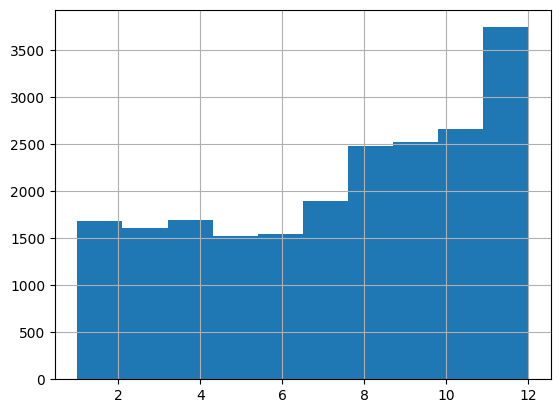

In [14]:
df["arrival_month"].hist()

In [15]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [16]:
df["type_of_meal_plan"].value_counts()

type_of_meal_plan
Meal Plan 1     16759
Not Selected     3627
Meal Plan 2       969
Meal Plan 3         4
Name: count, dtype: int64

<Axes: >

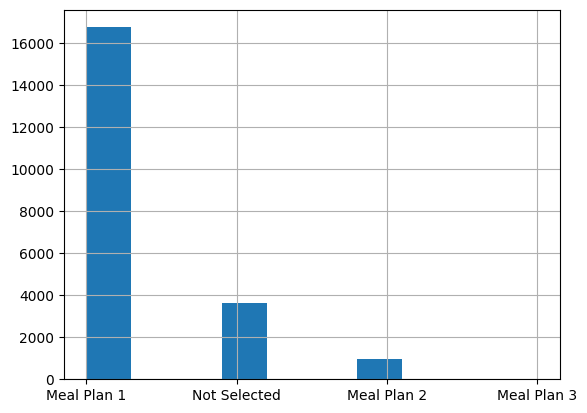

In [17]:
df["type_of_meal_plan"].hist()

In [18]:
df["required_car_parking_space"].value_counts()

required_car_parking_space
0    20452
1      907
Name: count, dtype: int64

### Important conclusion: Our data is imbalanced

In [19]:
categorical_columns = [
    "type_of_meal_plan",
    "required_car_parking_space",
    "room_type_reserved",
    "market_segment_type",
    "repeated_guest",
    "booking_status"
]

numerical_columns = [
    "no_of_adults",
    "no_of_children",
    "no_of_weekend_nights",
    "no_of_week_nights",
    "lead_time",
    "arrival_year",
    "arrival_month",
    "arrival_date",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room",
    "no_of_special_requests",
]

In [20]:
len(categorical_columns)

6

In [21]:
len(numerical_columns)

12

# Exploratory Data Analysis

In [22]:
data = df.copy()

In [23]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


## Unnivariate Data Analysis

This method aims to analyse features one by one in order to understand those **behavior**, **distribuction** and identify **patters** or **ouliers** individualy.

In [24]:
def num_plot_dist(df, num_features):
    """
    Improved visualization for numerical features in univariate data analysis.
    For each feature:
      - Plots a histogram with KDE and improved style.
      - Plots a horizontal boxplot beneath for better outlier visualization.
    """

    n_cols = 2
    n_rows = len(num_features)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

    if n_rows == 1:
        axes = [axes]

    for i, column in enumerate(num_features):
        # Histogram + KDE, customized
        ax_hist = axes[i][0]
        sns.histplot(
            df[column].dropna(), 
            bins='auto',
            ax=ax_hist, 
            kde=True, 
            color="steelblue",
            edgecolor="black"
        )
        ax_hist.set_title(f"Distribution of '{column}'", fontsize=12)
        ax_hist.set_xlabel(column, fontsize=10)
        ax_hist.set_ylabel("Count", fontsize=10)
        ax_hist.grid(True, which="major", axis='y', linestyle='--', alpha=0.5)
        ax_hist.set_facecolor("#f9fafc")

        # Boxplot, horizontal, more readable for detecting outliers
        ax_box = axes[i][1]
        sns.boxplot(
            data=df, 
            x=column, 
            ax=ax_box, 
            color="skyblue",
            linewidth=1.2, 
            fliersize=4, 
            orient='h', 
            boxprops=dict(alpha=.7)
        )
        ax_box.set_title(f"Boxplot of '{column}'", fontsize=12)
        ax_box.set_xlabel(column, fontsize=10)
        ax_box.set_yticks([])
        ax_box.set_facecolor("#f9fafc")
        # Optional: display Q1, median, Q3
        q1 = df[column].quantile(0.25)
        median = df[column].median()
        q3 = df[column].quantile(0.75)
        ax_box.axvline(median, color='red', linestyle='--', label='Median')
        ax_box.axvline(q1, color='green', linestyle=':', alpha=0.7, label='Q1')
        ax_box.axvline(q3, color='purple', linestyle=':', alpha=0.7, label='Q3')
        # Only add legend for first variable for clarity
        if i == 0:
            ax_box.legend(loc='upper right', fontsize=8)

        # Tighter x formatting if numeric
        if pd.api.types.is_numeric_dtype(df[column]):
            ax_box.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))

    plt.tight_layout(h_pad=2)
    plt.show()


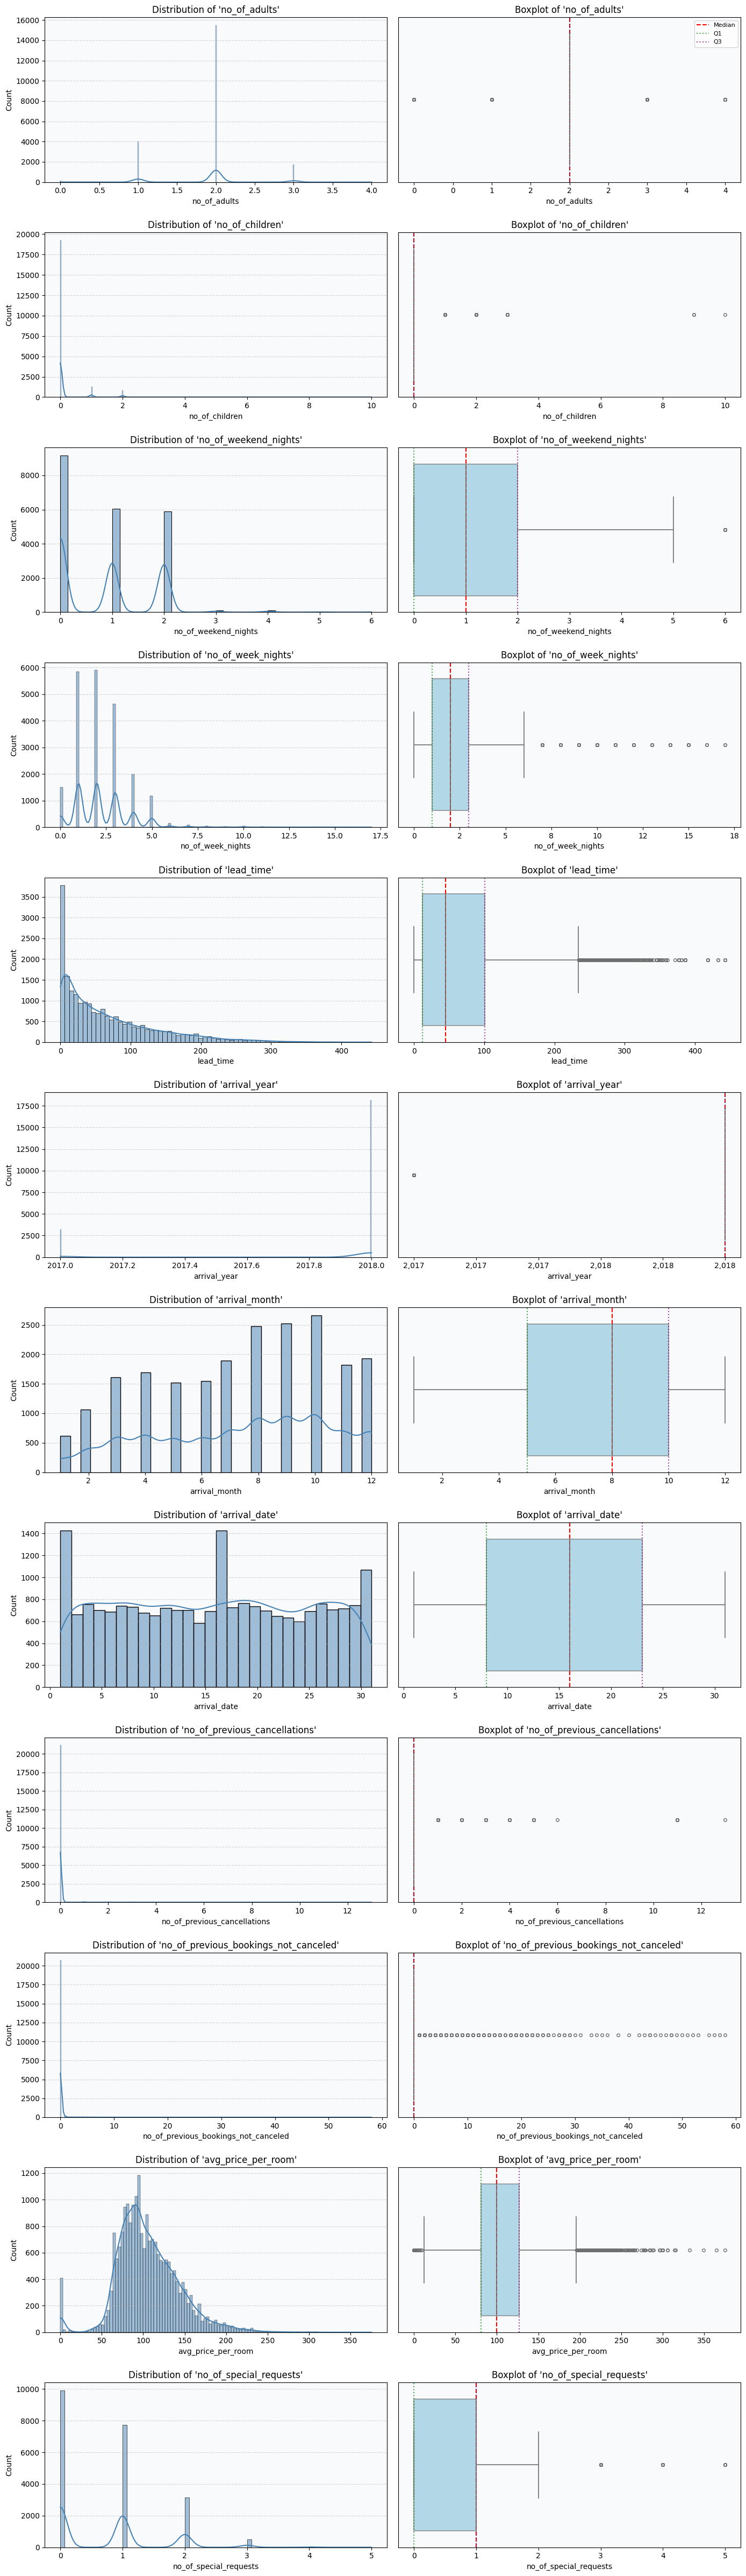

In [25]:
num_plot_dist(data, numerical_columns)

In [26]:
def cat_plot_dist(df, cat_features):
    n_cols = 2
    n_rows = int(np.ceil(len(cat_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for idx, cat_feature in enumerate(cat_features):
        # Bar plot for value counts (distribution of categories)
        ax = axes[idx]
        value_counts = df[cat_feature].value_counts(dropna=False).sort_values(ascending=False)
        bars = ax.bar(value_counts.index.astype(str), value_counts.values, color="skyblue", edgecolor="black")

        # Annotate count on top of each bar
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{int(height)}", 
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)
        
        # Make it pretty
        ax.set_title(f"Distribution of '{cat_feature}'", fontsize=13, fontweight='bold')
        ax.set_xlabel(cat_feature, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.set_facecolor("#f9fafc")
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
        
        # Optionally, show proportions as a secondary axis
        ax2 = ax.twinx()
        proportions = value_counts.values / value_counts.sum()
        ax2.plot(value_counts.index.astype(str), proportions, color='orange', marker='o', linestyle='dashed', label='Proportion')
        ax2.set_ylabel('Proportion', color='orange', fontsize=10)
        ax2.tick_params(axis='y', colors='orange')
        ax2.set_ylim(0, proportions.max() * 1.2)
        if idx == 0:
            ax2.legend(loc="upper right", fontsize=9)
        
    # Hide any unused subplots
    for i in range(len(cat_features), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(h_pad=2)
    plt.show()



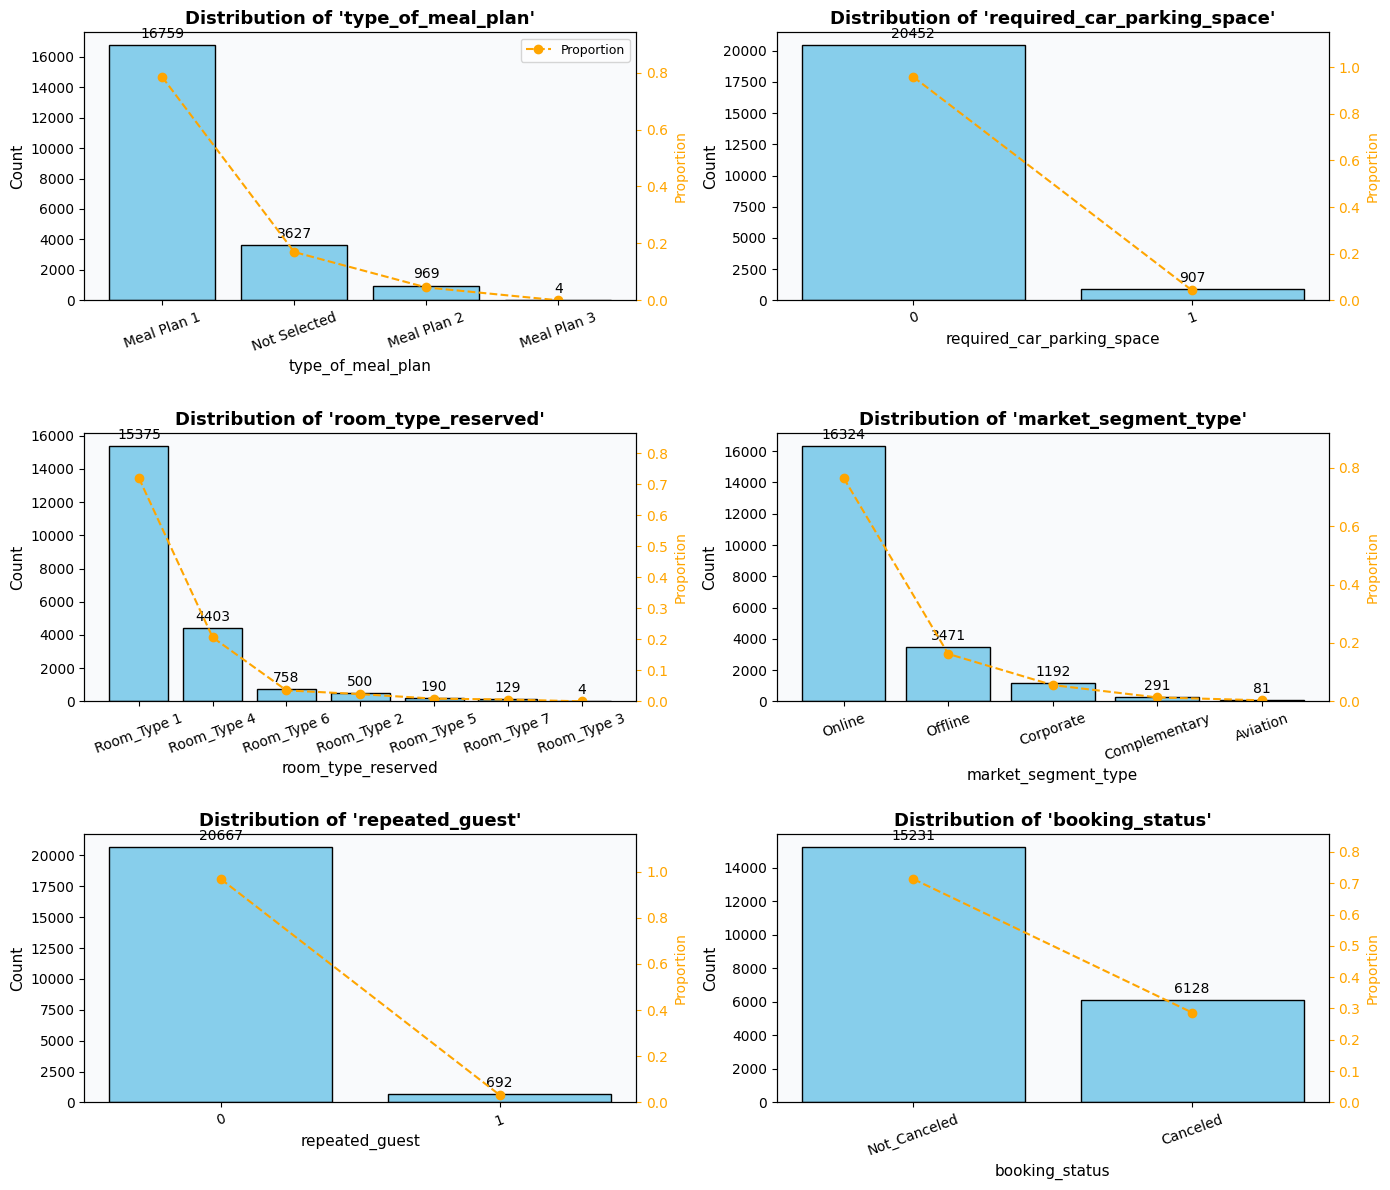

In [27]:
cat_plot_dist(data, categorical_columns)

Based on the above univariate analysis, we can consider excluding certain features from model training due to their low informational value for predictive modeling, despite their possible relevance for business insights. Specifically, the following features may be candidates for removal:
 - `arrival_year`
 - `required_car_parking`
 - `repeated_guest`
 - `no_of_previous_cancellations`
 - `no_of_previous_bookings_not_canceled`
 - `no_of_children`

For instance, `repeated_guest` comprises less than 1% of the total bookings, indicating minimal variance and limited predictive power. Similarly, `arrival_year` offers little distinction, as only about 1% of the records belong to the year 2017. In such cases, retaining these features could add noise rather than value to the machine learning models. However, it is important to note that their relevance from a business analysis perspective should be evaluated based on the specific goals of the analysis.

### Important: Our target are also imbalanced

## Bivariate Anallysis

Before remove those features mentioned above we must check the relation of then with the target unsing Bivariate Data Analysis.

In [28]:
def plot_bivariate_numnerical(df, target, numerical_features):
    num_plots= len(numerical_features)
    num_rows= (num_plots+1)//2

    fig, axes = plt.subplots(num_rows, 2, figsize=(15,num_rows*5))
    axes = axes.flatten()

    for i, column in enumerate(numerical_features):
        sns.boxplot(x=target, y=column, ax=axes[i], data=df, palette="Blues")
        axes[i].set_title(f"{column} vs {target}")

        plt.tight_layout()
        plt.show

C:\Users\Rondon\AppData\Local\Temp\ipykernel_19800\2577264727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=column, ax=axes[i], data=df, palette="Blues")
C:\Users\Rondon\AppData\Local\Temp\ipykernel_19800\2577264727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=column, ax=axes[i], data=df, palette="Blues")
C:\Users\Rondon\AppData\Local\Temp\ipykernel_19800\2577264727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=column, ax=axes[i], data=df, palette="Blues")
C:\Users\Rondon\AppData\Local\T

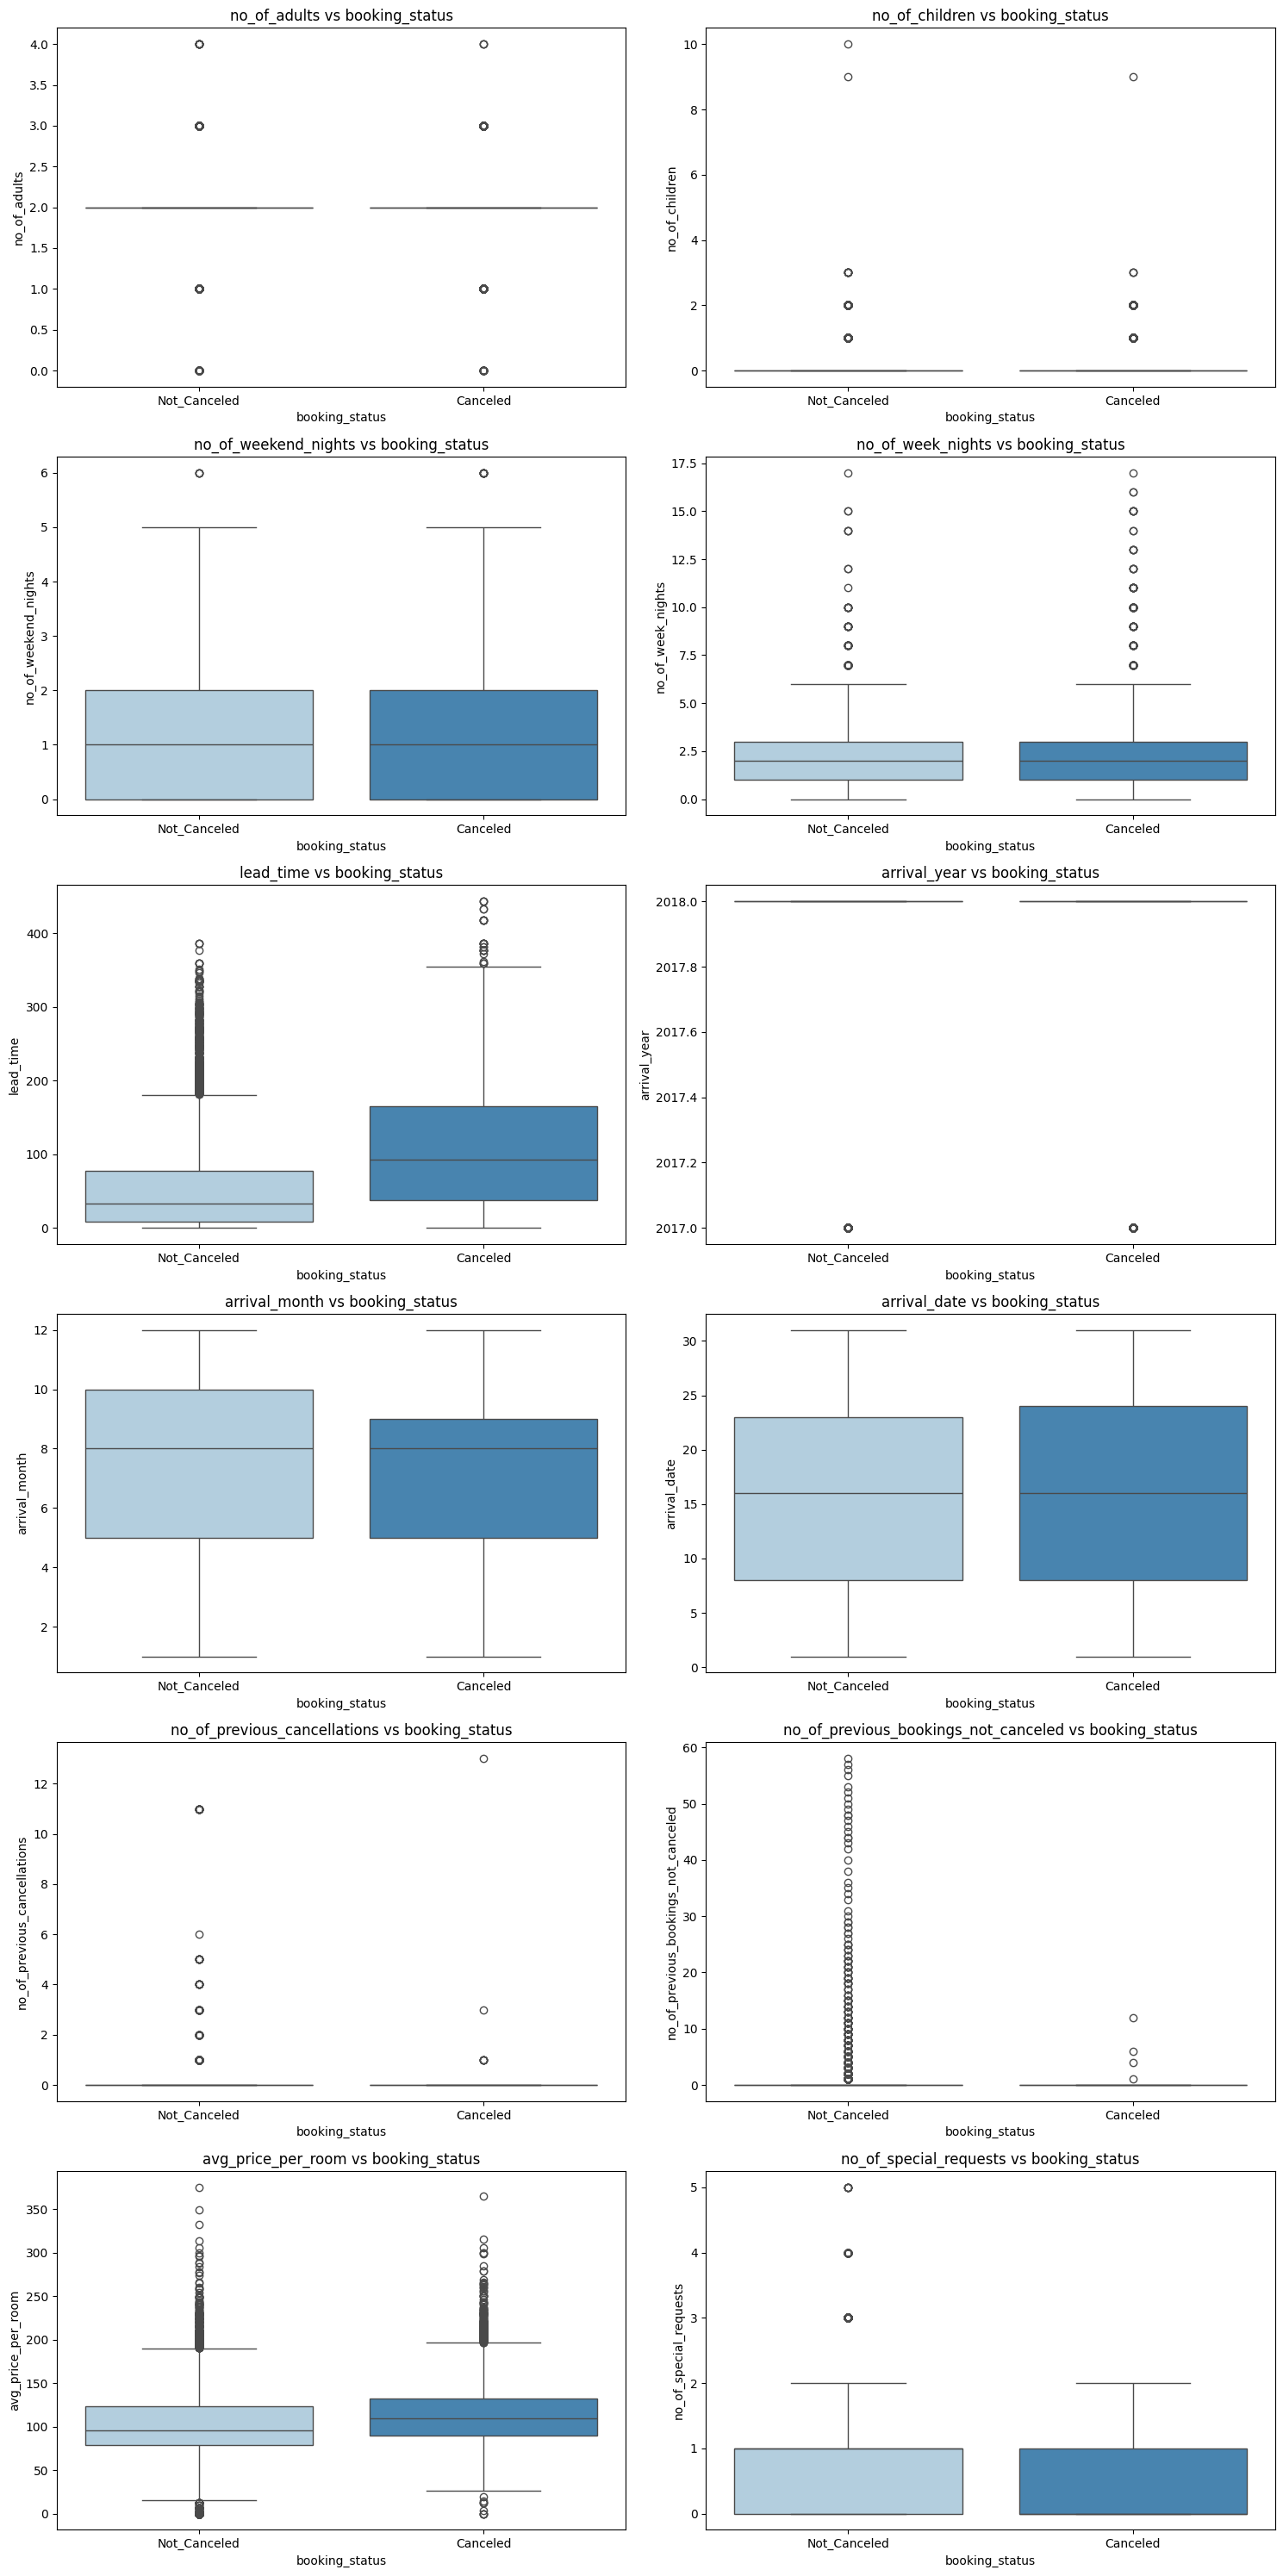

In [29]:
plot_bivariate_numnerical(data, "booking_status", numerical_columns)

In [30]:
def plot_bivariate_cat(df, target, categorical_columns):
    num_features=len(categorical_columns)
    num_rows=(num_features+1)//2

    fig, axes = plt.subplots(num_rows, 2, figsize=(15,num_rows*5))
    axes = axes.flatten()

    for i, feature in enumerate(categorical_columns):
        sns.countplot(x=feature, hue=target, data=df, palette="Set2", ax=axes[i])
        axes[i].set_title(f"{feature} vs {target}")
        axes[i].tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show

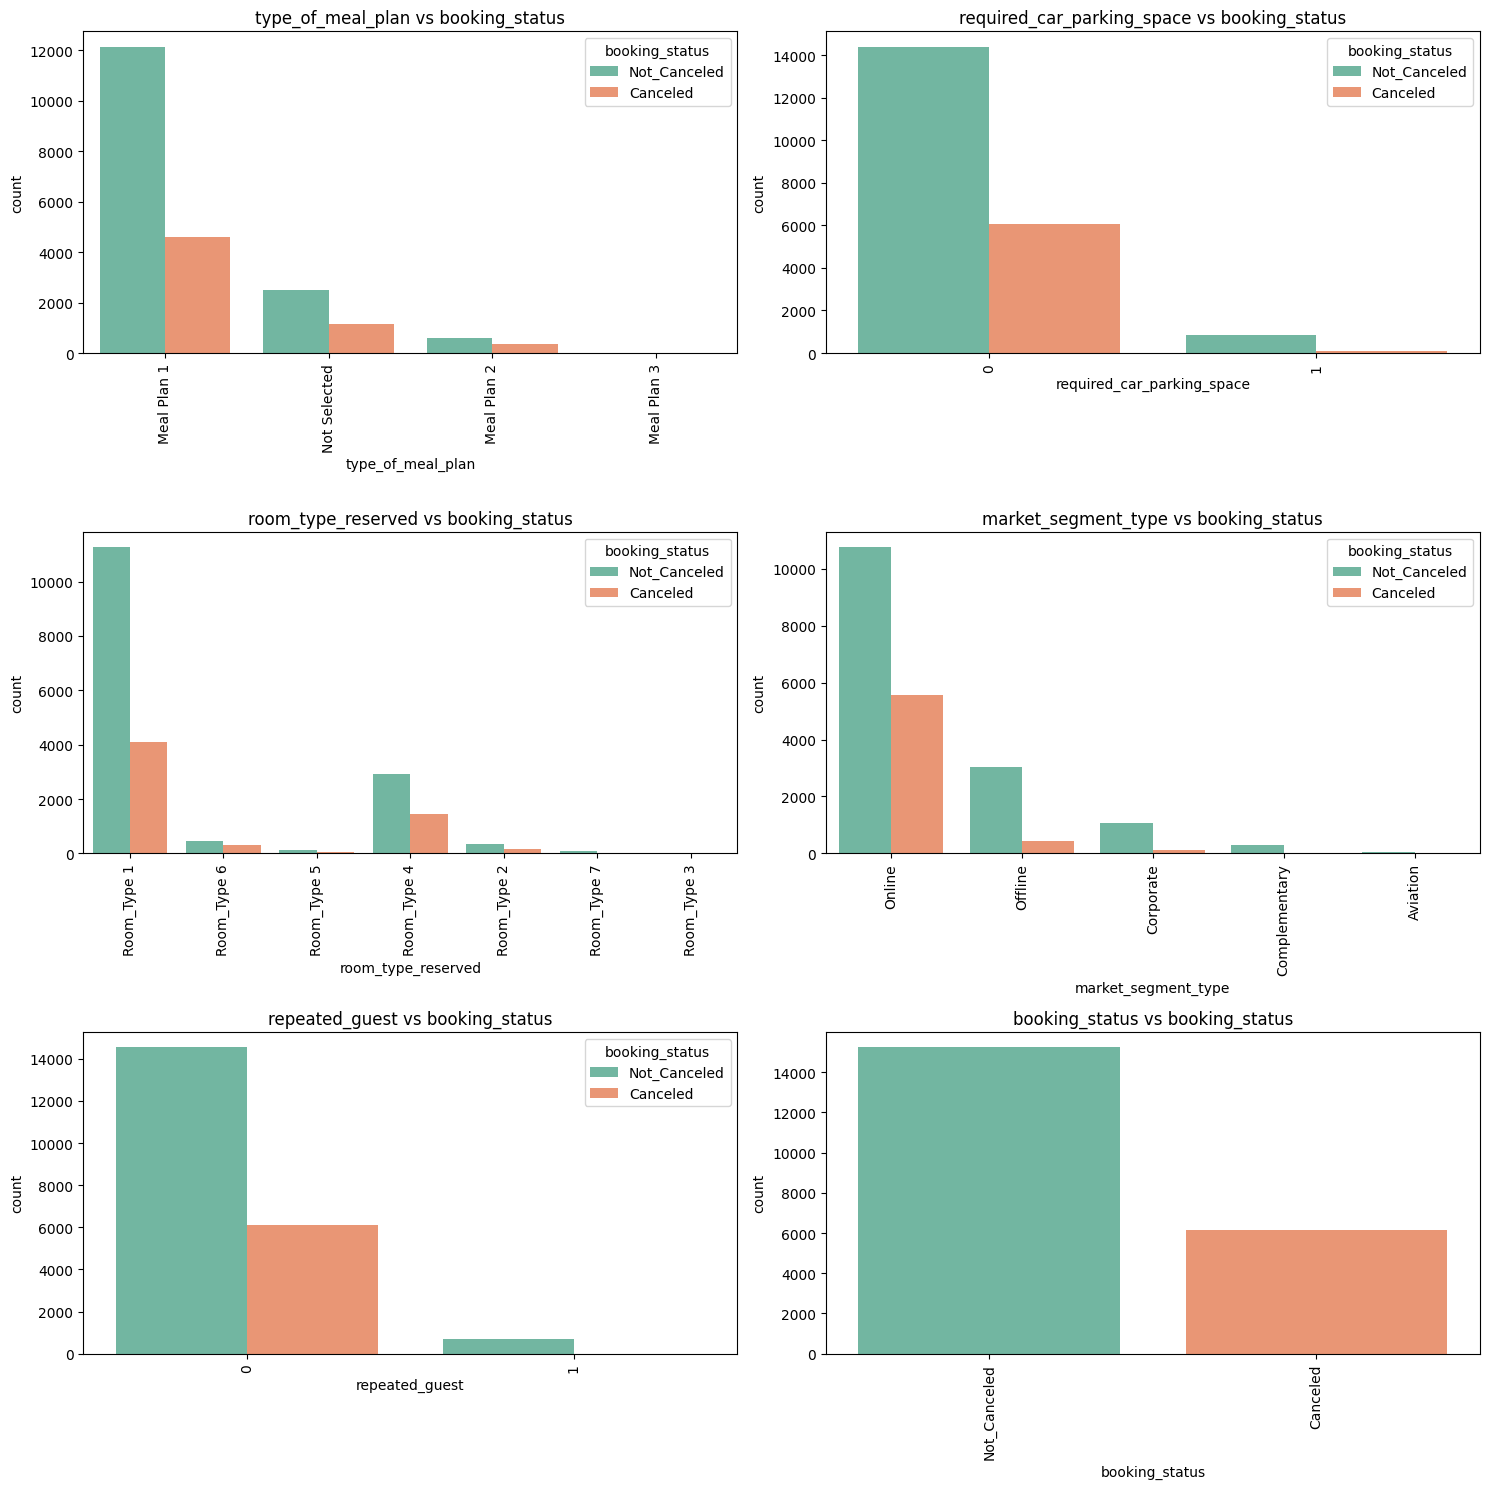

In [31]:
plot_bivariate_cat(df, "booking_status", categorical_columns)

Key Insights from Bivariate Analysis:
 
- `lead_time`: We observe a clear positive relationship between lead time and cancellation probability. Guests who book further in advance are significantly more likely to cancel their reservations. This trend suggests that `lead_time` is an important feature for modeling cancellations.
 
- `required_car_parking_space`: Bookings without a requested car parking space demonstrate a higher cancellation rate compared to those with parking requests. This may indicate that guests with a stronger commitment to their stay (as evidenced by booking a parking spot) are less likely to cancel.
 
- `room_type_reserved`: Certain room types, specifically `Room_Type 6`, `Room_Type 1`, and `Room_Type 4`, display markedly higher cancellation rates. This suggests that the type of room reserved is a significant categorical predictor for cancellations and warrants closer investigation (e.g., due to price, availability, or overbooking practices).
 
- `market_segment_type`: Bookings originating from the ‘Online’ market segment exhibit approximately a 50% cancellation rate, considerably higher than some other segments. This highlights the importance of channel-based segmentation for cancellation prediction.
 
- `repeated_guest`: Notably, repeat guests have an extremely low (approaching zero) cancellation rate. This underscores the value of capturing loyalty or repeat-customer features in our predictive model.
 
Overall, this analysis highlights several impactful features—such as `lead_time`, parking requirements, room type, booking channel, and guest loyalty—that should be prioritized during model development. Understanding these relationships not only informs feature selection but also points toward potential business strategies for reducing cancellations.

In [32]:
numerical_data = data.copy()
for col in categorical_columns:
    numerical_data[col] = numerical_data[col].astype('category').cat.codes

In [33]:
for col in categorical_columns:
    print(numerical_data[col].value_counts())

type_of_meal_plan
0    16759
3     3627
1      969
2        4
Name: count, dtype: int64
required_car_parking_space
0    20452
1      907
Name: count, dtype: int64
room_type_reserved
0    15375
3     4403
5      758
1      500
4      190
6      129
2        4
Name: count, dtype: int64
market_segment_type
4    16324
3     3471
2     1192
1      291
0       81
Name: count, dtype: int64
repeated_guest
0    20667
1      692
Name: count, dtype: int64
booking_status
1    15231
0     6128
Name: count, dtype: int64


In [34]:
# ### label encoding antoher way
# from sklearn.preprocessing import LabelEncoder

# label_encoder = LabelEncoder()

# mappings={}

# encoder_data = df.copy()

# for col in categorical_columns:
#     encoder_data[col] = label_encoder.fit_transform(data[col])

#     mappings[col]={label:code for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))}

## Multicollinearity

**Multicollinearity** refers to the presence of `strong associations among predictor variables.` In predictive modeling, this phenomenon is particularly relevant for linear and parametric models, where highly correlated predictors may lead to unstable coefficient estimates, inflated variance, and reduced interpretability. However, multicollinearity does not necessarily imply a degradation in predictive performance for all algorithms, especially for tree-based models and regularized methods.

A **correlation matrix** quantifies the degree of linear or monotonic association between pairs of variables. The main focus is on correlations among predictor variables, rather than correlations between predictors and the target variable.

**Multicollinearity can negatively** affect models that rely on coefficient estimation, such as linear regression and logistic regression, because it increases coefficient variance and reduces interpretability. However, it does not necessarily degrade predictive performance in all machine learning models, especially tree-based or regularized models.

`Severe multicollinearity should be diagnosed and mitigated` when model interpretability, coefficient stability, or feature importance analysis is a central objective.

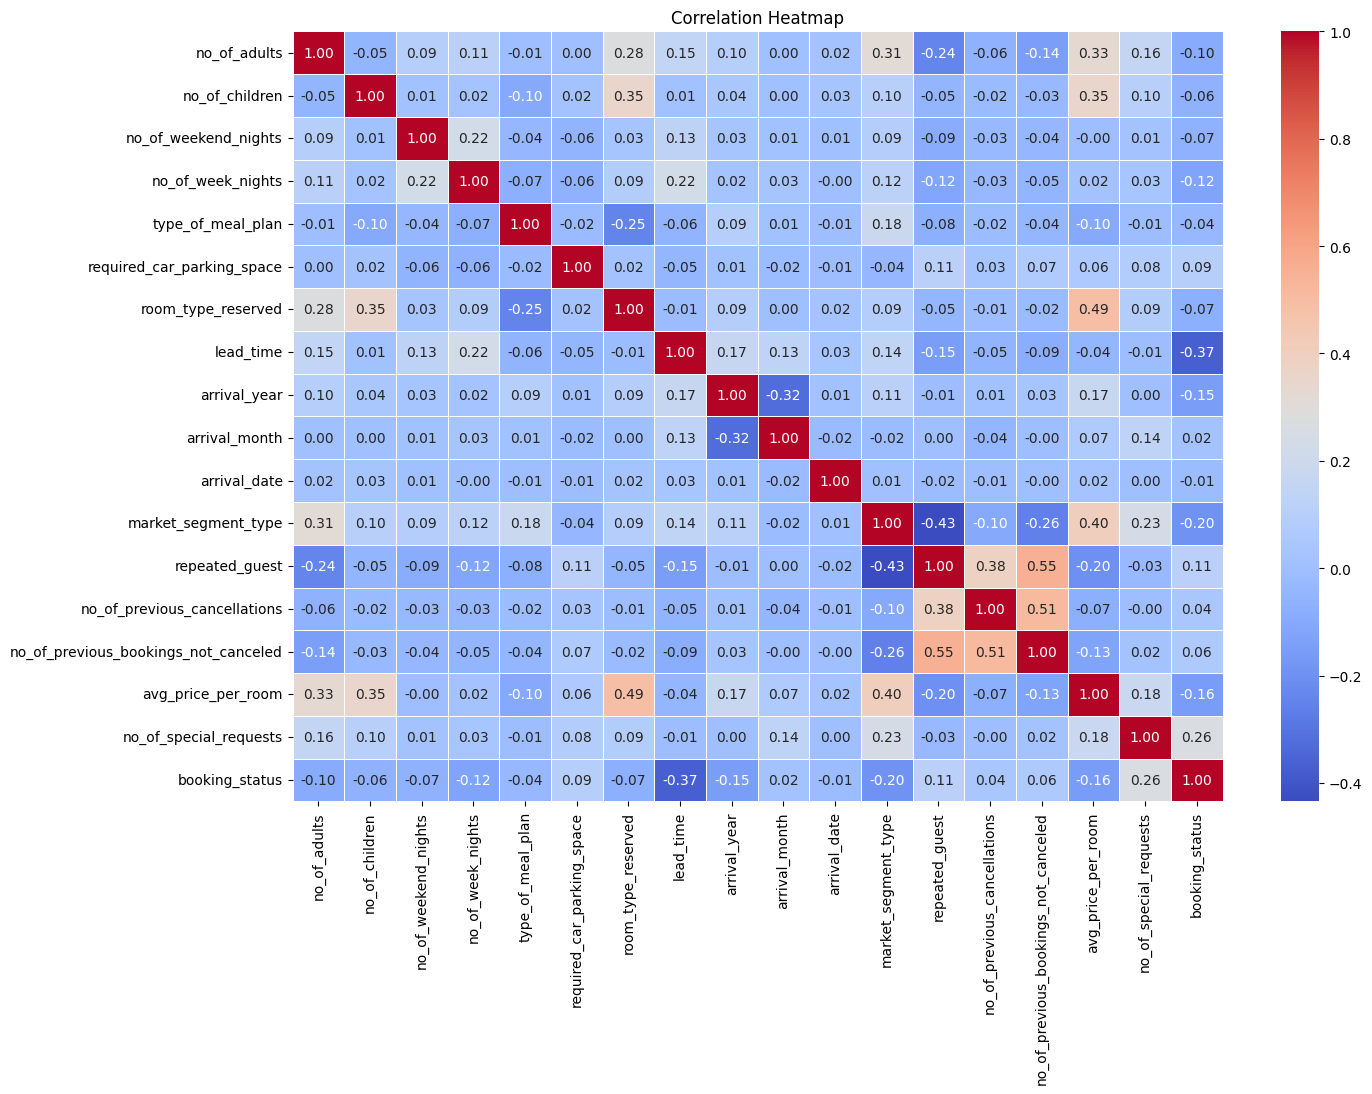

In [35]:
corr_matrix = numerical_data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

The correlation matrix provides valuable quantitative support for our previous bivariate findings. Notably, `lead_time` exhibits the strongest correlation with `booking_status`, reaffirming its critical role in predicting cancellations. Additionally, `no_of_week_nights`, although less directly correlated with `booking_status`, shows substantial correlation with `lead_time`; this relationship may introduce complex, potentially non-linear interactions in our predictive modeling and warrants further exploration.
 
Furthermore, the matrix reveals that `market_segment_type` maintains notable correlations with features such as `repeated_guest`, `avg_price_per_room`, and `no_of_special_requests`. These associations highlight distinct behavioral patterns among customer segments, suggesting that bookings from certain market segments—often characterized by specific pricing or loyalty behaviors—are more likely to share similar booking outcomes. 

Moving forward, these insights should inform our feature engineering and selection efforts, with particular attention paid to modeling non-linear relationships and considering potential interaction effects among highly correlated variables. This will help maximize predictive accuracy and enhance the interpretability of our model.

> **Overall**, the correlation analysis suggests that `lead_time, no_of_special_requests,` and some historical booking variables may be relevant predictors of booking cancellation. Nevertheless, the current matrix does not indicate severe multicollinearity among the predictors. Future modeling steps should therefore focus not only on removing correlated variables, but also on evaluating feature importance, non-linear effects, and interaction patterns using model-based diagnostics.

In [36]:
numerical_data.info()

<class 'pandas.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  int8   
 5   required_car_parking_space            21359 non-null  int8   
 6   room_type_reserved                    21359 non-null  int8   
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type            

In [37]:
X = add_constant(numerical_data)

vif_data = pd.DataFrame()

vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

vif_data

,feature,VIF
0,const,4.100197e+07
1,no_of_adults,1.341180e+00
2,no_of_children,1.282459e+00
3,no_of_weekend_nights,1.073215e+00
4,no_of_week_nights,1.125260e+00
5,type_of_meal_plan,1.178228e+00
6,required_car_parking_space,1.036105e+00
7,room_type_reserved,1.549859e+00
8,lead_time,1.406287e+00
9,arrival_year,1.288533e+00


#### Variance Inflation Factor

To complement the correlation heatmap, the Variance Inflation Factor (VIF) was computed to assess the presence of multicollinearity among the predictor variables. While the correlation matrix provides pairwise associations, VIF evaluates whether each predictor can be linearly explained by a combination of the remaining predictors. Therefore, VIF provides a more direct diagnostic of multicollinearity in the feature space.

The VIF for a predictor $(X_j)$ is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $(R_j^2)$ is obtained by regressing $(X_j)$ on all other predictor variables. A VIF close to $1$ indicates that the variable is almost independent from the remaining predictors, whereas larger values indicate increasing linear redundancy.

In this analysis, all predictor-level VIF values were below 2.0. The highest values were observed for `avg_price_per_room` (`VIF = 1.93`), `repeated_guest` (`VIF = 1.77`), `no_of_previous_bookings_not_canceled` (`VIF = 1.71`), and `market_segment_type` (`VIF = 1.70`). These values are well below conventional thresholds of concern, commonly defined as `VIF > 5` for moderate multicollinearity and `VIF > 10` for severe multicollinearity.

Therefore, the VIF results indicate that the dataset does not present problematic multicollinearity among the selected predictors. This finding is consistent with the correlation heatmap, where most pairwise correlations among independent variables were weak to moderate. Consequently, there is no immediate statistical justification for removing predictors solely due to multicollinearity.

The extremely high VIF observed for the constant term should not be interpreted as evidence of multicollinearity among the features. The constant represents the model intercept and is not an explanatory variable. Such inflated values may occur when predictors are not centered, particularly when variables such as `arrival_year` contain large numerical values. Hence, the intercept should be excluded from the substantive interpretation.

It is also important to note that VIF should be computed only on the independent variables. The target variable, `booking_status`, should not be included in the VIF matrix because multicollinearity concerns redundancy among predictors, not association with the outcome. Therefore, the reported VIF value for `booking_status` is not relevant for the multicollinearity diagnosis.

Overall, the VIF analysis suggests that the feature set is suitable for subsequent modeling from a multicollinearity perspective. Future feature selection should therefore be guided by predictive performance, feature importance, domain relevance, and model interpretability rather than by multicollinearity removal.


> The VIF analysis does not indicate severe multicollinearity among the predictors. All feature-level VIF values are below 2.0, suggesting that no predictor is strongly linearly explained by the remaining variables. Therefore, the dataset does not require feature removal based on multicollinearity criteria. However, the target variable should be excluded from VIF computation, and nominal categorical variables should preferably be one-hot encoded before applying this diagnostic.


## Skewness

**Skewness analysis measures the asymmetry of a variable’s distribution** around its mean, quantifies whether a distribution has a longer tail on one side. It helps identify whether the data are approximately symmetric, right-skewed, or left-skewed.

However, skewness is not always something that must be “fixed.” Whether we need to correct it depends on the model, the feature type, and the objective of the analysis.

Skewness quantifies whether a distribution has a longer tail on one side.

##### Positive Skewness

A variable has **positive skewness** when most observations are concentrated at low values, but a few observations are very large.

```text
mean > median
```

##### Negative Skewness

A variable has **negative skewness** when most observations are concentrated at high values, but a few observations are much smaller.

```text
mean < median
```

##### Approximately Symmetric Distribution

A variable is approximately symmetric when the left and right tails are balanced.

```text
mean ≈ median
```

#### Mathematical Definition

The sample skewness can be understood as the standardized third central moment:

$$
\text{Skewness} =
\frac{E[(X - \mu)^3]}{\sigma^3}
$$

where:

* $(X)$ is the variable;
* $(\mu)$ is the mean;
* $(\sigma)$ is the standard deviation.

The cubic term $((X - \mu)^3)$ makes the metric sensitive to the direction and magnitude of asymmetry.

#### heuristic

A common heuristic is:

|                         Skewness Value | Interpretation          |
| -------------------------------------: | ----------------------- |
|                        (-0.5) to (0.5) | approximately symmetric |
|     (0.5) to (1.0) or (-1.0) to (-0.5) | moderately skewed       |
| greater than (1.0) or less than (-1.0) | highly skewed           |


In [38]:
skewness = numerical_data.skew()

In [39]:
skewness

no_of_adults                            -0.305652
no_of_children                           4.165696
no_of_weekend_nights                     0.636637
no_of_week_nights                        1.553657
type_of_meal_plan                        1.650716
required_car_parking_space               4.538315
room_type_reserved                       1.392145
lead_time                                1.405258
arrival_year                            -1.953273
arrival_month                           -0.293266
arrival_date                             0.010333
market_segment_type                     -2.333046
repeated_guest                           5.282330
no_of_previous_cancellations            22.001489
no_of_previous_bookings_not_canceled    16.735934
avg_price_per_room                       0.542888
no_of_special_requests                   0.922373
booking_status                          -0.942305
dtype: float64

In [40]:
# skew_solv_data = numerical_data.copy()

In [41]:
# ## Log transform

# for col in skew_solv_data.columns:
#     if skewness[col] > 5:
#         skew_solv_data[col] = np.log1p(skew_solv_data[col])

In [42]:
# skewness = skew_solv_data.skew()

# skewness

# [Imbalance solving](https://imbalanced-learn.org/stable/index.html)

Our dataset are imbalanced containing $15231$ samples about non canceled books and $6128$ and to solve this we need to **over sampling** our data applying smart technique called [SMOTE - Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813) to perform **over-sampling** from imbalanced-learn api.

<Axes: >

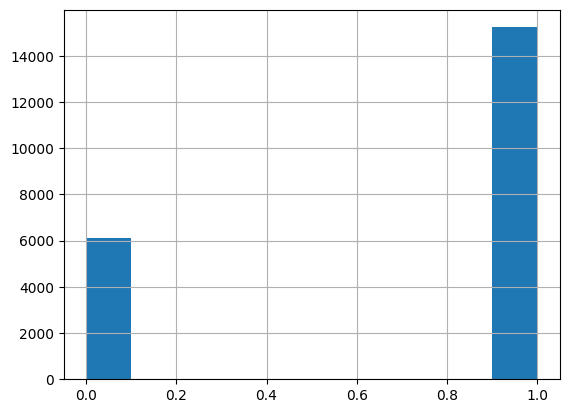

In [43]:
numerical_data["booking_status"].hist()

In [44]:
numerical_data["booking_status"].value_counts()

booking_status
1    15231
0     6128
Name: count, dtype: int64

In [45]:
X = numerical_data.drop(columns='booking_status')
y = numerical_data["booking_status"]

In [46]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X,y)

In [47]:
y_res.value_counts()

booking_status
1    15231
0    15231
Name: count, dtype: int64

In [48]:
balanced_df = pd.DataFrame(X_res, columns=X.columns)
balanced_df["booking_status"] = y_res

In [49]:
balanced_df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,1,2,1,0,0,0,26,2017,10,17,4,0,0,0,161.00,0,1
1,2,1,1,1,0,0,0,98,2018,7,16,4,0,0,0,121.50,2,1
2,2,0,0,3,0,0,0,433,2018,9,8,3,0,0,0,70.00,0,0
3,2,0,2,5,0,0,0,195,2018,8,8,3,0,0,0,72.25,0,1
4,1,0,0,2,0,0,0,188,2018,6,15,3,0,0,0,130.00,0,0


In [50]:
balanced_df.shape

(30462, 18)

# Feature Selection

In [51]:
X = balanced_df.drop(columns='booking_status')
y = balanced_df["booking_status"]

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
feature_importance = model.feature_importances_

In [54]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "importance": feature_importance
})

In [55]:
feature_importance_df.sort_values(by="importance", ascending=False)

,Feature,importance
7,lead_time,0.261063
16,no_of_special_requests,0.185948
15,avg_price_per_room,0.148833
9,arrival_month,0.087250
10,arrival_date,0.084866
11,market_segment_type,0.057700
3,no_of_week_nights,0.044239
2,no_of_weekend_nights,0.029606
4,type_of_meal_plan,0.019887
6,room_type_reserved,0.019185


We can noticed that the model confirm our expectations about the main features based on the previous analysis. 

In [56]:
top_features_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
top_10_features = top_features_importance_df["Feature"].head(10).values
top_10_df = balanced_df[top_10_features.tolist() + ["booking_status"]]

In [57]:
top_10_df.head()

,lead_time,no_of_special_requests,avg_price_per_room,arrival_month,arrival_date,market_segment_type,no_of_week_nights,no_of_weekend_nights,type_of_meal_plan,room_type_reserved,booking_status
0,26,0,161.00,10,17,4,1,2,0,0,1
1,98,2,121.50,7,16,4,1,1,0,0,1
2,433,0,70.00,9,8,3,3,0,0,0,0
3,195,0,72.25,8,8,3,5,2,0,0,1
4,188,0,130.00,6,15,3,2,0,0,0,0


In [58]:
top_10_df.shape

(30462, 11)

# Model Selection

In [61]:
X = top_10_df.drop(columns='booking_status')
y = top_10_df["booking_status"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [63]:
classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Suport Vector Machine": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42),
    "Adaboost": AdaBoostClassifier(random_state=42),
    "LGBM": LGBMClassifier(random_state=42)
}

In [72]:
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

In [74]:
for model_name, classifier in classifiers.items():
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics["Model"].append(model_name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)

c:\Users\Rondon\Documents\1. Python Starter\24.hotel_revervation_ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
metrics_df = pd.DataFrame(metrics)

In [76]:
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.891843,0.891015,0.894788,0.892898
1,Logistic Regression,0.775808,0.801700,0.737459,0.768239
2,Gradient Boosting,0.835057,0.818771,0.863844,0.840704
3,Suport Vector Machine,0.720171,0.729412,0.706840,0.717949
4,Decision Tree,0.840473,0.849434,0.830619,0.839921
5,KNN,0.780075,0.856554,0.676873,0.756186
6,Naive Bayes,0.773511,0.803520,0.728664,0.764264
7,XGBoost,0.872148,0.867737,0.880456,0.874050
8,Adaboost,0.804366,0.800769,0.814332,0.807494
9,LGBM,0.864270,0.850140,0.886971,0.868165


## Tunning the best 3 models hyperparameters

In [79]:
rfc = RandomForestClassifier(random_state=42)

In [82]:
params_distribution={
    'n_estimators': randint(100,500),
    'max_depth': randint(10,50),
    'min_samples_split': randint(2,10),
    'min_samples_leaf': randint(1,5),
    'bootstrap': [True, False]
}

In [83]:
random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=params_distribution,
    n_iter=5,
    cv=5,
    verbose=2,
    random_state=42,
    scoring='accuracy'
)

In [84]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   2.2s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   2.2s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   2.0s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   2.0s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   2.1s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   3.7s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   3.7s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   3.7s
[CV]

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': <scipy.stats....002DCE0F13800>, 'min_samples_leaf': <scipy.stats....002DCE0178710>, 'min_samples_split': <scipy.stats....002DCE0179DF0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the var

In [85]:
random_search.best_params_

{'bootstrap': False,
 'max_depth': 33,
 'min_samples_leaf': 3,
 'min_samples_split': 7,
 'n_estimators': 408}

In [86]:
best_rf_model = random_search.best_estimator_

In [87]:
y_pred = best_rf_model.predict(X_test)

In [88]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [89]:
accuracy

0.890365993763335

## Save the model

In [91]:
joblib.dump(best_rf_model,"random_forest.pkl")

['random_forest.pkl']

## Load the model

In [92]:
loaded_best_model = joblib.load("random_forest.pkl")

In [93]:
### Simulate prediction

new_data = X_train[0:1]

In [94]:
prediction = loaded_best_model.predict(new_data)

In [97]:
y_train[0:1]

4157    1
Name: booking_status, dtype: int8

In [100]:
print(f"prediction{prediction}, real value {y_train[0:1]}")

prediction[1], real value 4157    1
Name: booking_status, dtype: int8


After checking the model size, we can see that the serialized Random Forest model is almost **180 MB**. Because of this, it is worth evaluating a smaller model, such as **LightGBM**.

## LGBM 

In [103]:
lgbm = LGBMClassifier(random_state=42)

In [107]:
lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [108]:
y_pred = lgbm.predict(X_test)

In [109]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [110]:
accuracy

0.8642704743147874

In [111]:
joblib.dump(lgbm,"lgbm.pkl")

['lgbm.pkl']

Currently, we have two different models:

| Model                    | Accuracy | Serialized Size |
| ------------------------ | -------: | --------------: |
| Random Forest Classifier |     0.89 |          180 MB |
| LightGBM                 |     0.86 |          330 KB |

Although the Random Forest model achieved slightly better accuracy, it is significantly larger than the LightGBM model. LightGBM has a small reduction in accuracy, but its serialized size is much smaller.

Therefore, the final model choice will depend on the business requirements and technical constraints. If maximum accuracy is the main priority, the Random Forest model may be preferred. However, if model size, deployment efficiency, loading time, or resource usage are important, LightGBM may be the better option.
